d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


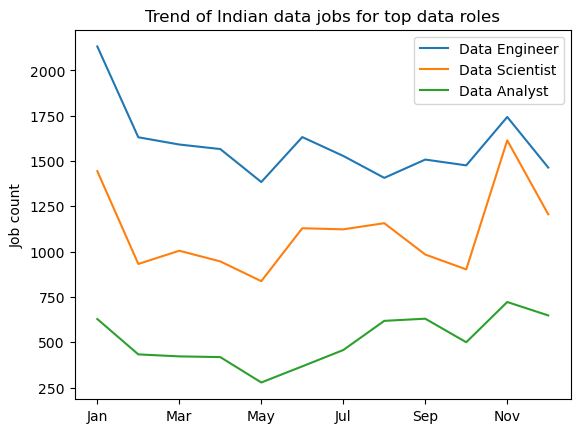

In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#Filtering for only indian data jobs
df_india = df[df['job_country'] == 'India'].copy()

#Creating two new columns for job date month and month no
df_india['job_posted_month'] = df_india.job_posted_date.dt.strftime('%b')
df_india['job_posted_month_no'] = df_india.job_posted_date.dt.month

#Creating the pivot table by month as index and job titles as columns
df_india_pivot = df_india.pivot_table(index=['job_posted_month_no','job_posted_month'], columns='job_title_short', aggfunc='size')

#Sorting the table using that month no column and dropping it to assign the index to month name column
df_india_pivot = df_india_pivot.sort_index().reset_index(level=0, drop=True)

#Filtering the pivot table by top 3 job titles
top_3 = df_india.value_counts('job_title_short').head(3).index.to_list()

#Plotting
df_india_pivot[top_3].plot(kind='line')
plt.title('Trend of Indian data jobs for top data roles')
plt.xlabel('')
plt.ylabel('Job count')
plt.legend(title='')
plt.show()


In [2]:
df_india_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
Jan,175,31,628,2132,1444,70,127,448,269,192
Feb,143,35,433,1631,932,42,94,313,165,157
Mar,116,37,422,1591,1005,34,96,351,194,180
Apr,170,32,418,1566,946,54,86,375,194,169
May,103,14,278,1384,837,31,59,329,134,98
Jun,146,26,367,1632,1129,41,66,427,238,125
Jul,142,25,457,1528,1123,54,75,359,204,155
Aug,189,25,618,1407,1157,47,126,343,235,148
Sep,155,34,630,1508,984,67,85,324,195,132


In [18]:
# df_pd.read_csv("https://lukeb.co/software_csv", index_col="job_posted_month")

In [6]:
import pandas as pd
import numpy as np

# Set seed for reproducibility (optional)
np.random.seed(42)

# Create months list
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

# Generate random values between 100 and 600
data_example = {
    "job_posted_month": months,
    "Front-End Developer": np.random.randint(100, 601, 12),
    "Back-End Developer": np.random.randint(100, 601, 12),
    "Full-Stack Developer": np.random.randint(100, 601, 12),
    "UI/UX Designer": np.random.randint(100, 601, 12)
}

# Create DataFrame
df_india_pivot_2 = pd.DataFrame(data_example)

# Set month as index
df_india_pivot_2.set_index("job_posted_month", inplace=True)

df_india_pivot_2

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
Jan,202,430,591,335
Feb,535,558,513,444
Mar,448,187,393,148
Apr,370,472,485,574
May,206,199,291,158
Jun,171,459,543,269
Jul,288,251,376,575
Aug,120,230,260,287
Sep,202,249,559,563


In [8]:
df_india_final_pivot = df_india_pivot.merge(df_india_pivot_2, on='job_posted_month')
df_india_final_pivot

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
Jan,175,31,628,2132,1444,70,127,448,269,192,202,430,591,335
Feb,143,35,433,1631,932,42,94,313,165,157,535,558,513,444
Mar,116,37,422,1591,1005,34,96,351,194,180,448,187,393,148
Apr,170,32,418,1566,946,54,86,375,194,169,370,472,485,574
May,103,14,278,1384,837,31,59,329,134,98,206,199,291,158
Jun,146,26,367,1632,1129,41,66,427,238,125,171,459,543,269
Jul,142,25,457,1528,1123,54,75,359,204,155,288,251,376,575
Aug,189,25,618,1407,1157,47,126,343,235,148,120,230,260,287
Sep,155,34,630,1508,984,67,85,324,195,132,202,249,559,563


In [12]:
top_5 = (
    df_india_final_pivot.
    sum().
    sort_values(ascending=False).
    head(5).
    index.
    to_list()
    )
top_5

['Data Engineer',
 'Data Scientist',
 'Data Analyst',
 'Full-Stack Developer',
 'UI/UX Designer']

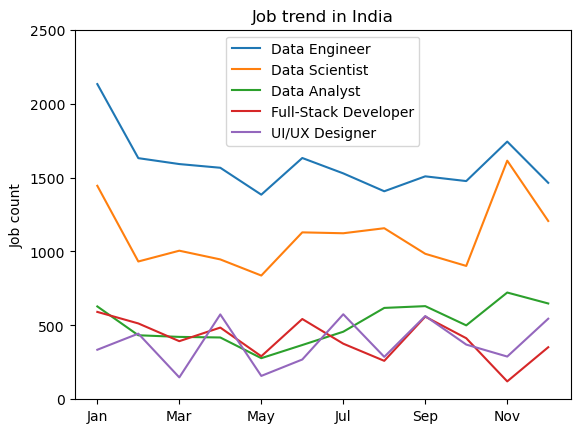

In [17]:
df_india_final_pivot[top_5].plot(kind='line')
plt.ylim(0,2500)
plt.xlabel('')
plt.ylabel('Job count')
plt.title('Job trend in India')
plt.show()